<a href="https://colab.research.google.com/github/cankurt-netizen/DSA210-PROJECT/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Machine Learning Analysis of Saudi Date Producer Prices

## Objective

*   This section uses machine learning models to predict the
log-transformed producer price of Saudi Arabian dates
using supply, demand, weather, and lag variables.



## 1) Uploading Data Files




*   We upload all the data files before starting the data cleaning and organization.



In [2]:
from google.colab import files
uploaded = files.upload()

Saving production (2).csv to production (2).csv
Saving balance.csv to balance.csv
Saving prices.csv to prices.csv
Saving search.csv to search.csv
Saving weather.csv to weather.csv


## 2) Cleaning and Data Integration



*   We start the data cleaning to create a proper data set for machine learning.
This final dataset combines yearly production, trade, producer price, weather, and Google Trends data for
Saudi Arabia’s dates market between 2000–2024.





In [3]:

# Import data analysis and numerical computation libraries

import pandas as pd
import numpy as np

# Import machine learning models and evaluation tools

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

# Define the folder path containing all CSV datasets

DATA = "/content/"

#-------------------------------
# Production Dataset Processing
#-------------------------------

# Load production-related data from FAOSTAT CSV
prod_raw = pd.read_csv(DATA + "production (2).csv")

# Filter the dataset to only include years between 2000 and 2024
prod = prod_raw[prod_raw["Year"].between(2000, 2024)]

# Convert long-format data into wide-format table
# Each production element becomes a separate column
prod_pivot = prod.pivot_table(index="Year", columns="Element", values="Value", aggfunc="sum")

# Clean column names for easier analysis
prod_pivot.columns = [c.strip().replace(" ", "_").lower() for c in prod_pivot.columns]

#-----------------------
# Trade Balance Dataset
#-----------------------

bal_raw = pd.read_csv(DATA + "balance.csv")

bal = bal_raw[bal_raw["Year"].between(2000, 2024)]

# Pivot yearly export and import quantities
bal_pivot = bal.pivot_table(index="Year", columns="Element", values="Value", aggfunc="sum")

bal_pivot.columns = ["export_qty", "import_qty"]

#------------------------
# Producer Price Dataset
#------------------------

prices_raw = pd.read_csv(DATA + "prices.csv")

prices_yr = (
    prices_raw[
        (prices_raw["Year"].between(2000, 2024)) &
        (prices_raw["Element"] == "Producer Price (USD/tonne)")
    ][["Year", "Value"]]
    .rename(columns={"Value": "producer_price"})
    .set_index("Year")["producer_price"]
)

#---------------------------
# Google Trends Search Data
#---------------------------

search_raw = pd.read_csv(DATA + "search.csv")

search_raw["Time"] = pd.to_datetime(search_raw["Time"])
search_raw["Year"] = search_raw["Time"].dt.year

# Aggregate Google Trends search interest by year
search_yr = (
    search_raw[search_raw["Year"].between(2000, 2024)]
    .groupby("Year")["تمر"]
    .mean()
    .rename("search_index")
)

#----------------------------
# Weather Dataset Processing
#----------------------------

# skiprows=2 removes unnecessary metadata rows
weather_raw = pd.read_csv(DATA + "weather.csv", skiprows=2)

weather_raw.columns = ["date", "temp_max", "temp_min", "precip"]
weather_raw["date"] = pd.to_datetime(weather_raw["date"], errors="coerce")
weather_raw = weather_raw.dropna(subset=["date"])
weather_raw["Year"] = weather_raw["date"].dt.year

weather_raw[["temp_max", "temp_min", "precip"]] = (
    weather_raw[["temp_max", "temp_min", "precip"]]
    .apply(pd.to_numeric, errors="coerce")
)

# Aggregate daily weather data into yearly indicators
weather_yr = (
    weather_raw[weather_raw["Year"].between(2000, 2024)]
    .groupby("Year")
    .agg(
        avg_temp_max=("temp_max", "mean"),
        avg_temp_min=("temp_min", "mean"),
        total_precip=("precip", "sum"),
        precip_days=("precip", lambda x: (x > 0).sum()),
    )
    .round(2)
)

#--------------------
# Merge All Datasets
#--------------------

# Combine all processed datasets into one master dataframe
master = (
    prod_pivot
    .join(bal_pivot, how="left")
    .join(prices_yr, how="left")
    .join(search_yr, how="left")
    .join(weather_yr, how="left")
)

master.index.name = "Year"
master = master.sort_index()

# Remove rows missing key variables
master = master.dropna(subset=["producer_price", "production"])

# --------------------
# Feature Engineering
# --------------------

# Create lag variables to capture delayed market effects
for col in ["producer_price", "production", "export_qty",
            "yield", "search_index"]:
    master[f"{col}_lag1"] = master[col].shift(1)

# Create yearly trend variable
master["year_trend"] = master.index - 2000

# Calculate net exports
master["net_exports"] = master["export_qty"] - master["import_qty"]

# Log transformation helps reduce skewness in producer prices
master["log_price"] = np.log(master["producer_price"].replace(0, np.nan))

# Final dataset used for machine learning analysis
master_model = master.copy()

print(master_model)


      area_harvested  production    yield  export_qty  import_qty  \
Year                                                                
2000        142450.0   734844.00   5158.6    28248.05      109.22   
2001        139099.0   817887.00   5879.9    31881.00       86.00   
2002        139979.0   829540.00   5926.2    33925.00      733.00   
2003        141421.0   884088.00   6251.5    34875.00     1978.00   
2009        161975.0   991660.00   6122.3    47059.00     1232.00   
2010        155118.0   991546.00   6392.2    73362.00     4053.00   
2011        156023.0  1008105.00   6461.3    77795.00    47026.00   
2012        156848.0  1031082.00   6573.8    70314.00     5783.00   
2013        156901.0  1095158.00   6979.9    99770.00     3109.00   
2014        107281.0   656807.00   6122.3   131977.00      495.00   
2015        109427.0  1038530.00   9490.6   120358.00     1223.00   
2016        111615.0  1153009.00  10330.2   131568.00      258.00   
2017        113848.0  1224192.00  

## 3) Machine Learning Process



* We apply and compare different machine learning feature groups
to predict the log-transformed producer price of Saudi dates.



In [4]:
#-------------------------------------------
# Define Target Variable and Feature Groups
#-------------------------------------------

# Target Variable and Feature Groups
TARGET = "log_price"

# Group features into Supply, Demand, Weather, and Lag categories
feature_sets = {
    "Supply": ["production_lag1","yield_lag1","year_trend"],
    "Demand": ["export_qty_lag1","search_index","net_exports"],
    "Weather": ["avg_temp_max","avg_temp_min","total_precip","precip_days"],
    "Lag": ["producer_price_lag1","production_lag1","export_qty_lag1", "yield_lag1", "search_index_lag1"]
}

#----------------------------------------------
# Create Validation Method and Results Storage
#----------------------------------------------

# Use Leave-One-Out Cross Validation because the dataset is small
loo = LeaveOneOut()

# Store model results and feature importance values
results = {}

print("\nModel results using log producer price")
print(f"{'Model':<15} {'RF R2':>8} {'RF MAE':>10} {'Ridge R2':>10} {'Ridge MAE':>12}")
print("-" * 60)

#---------------------------
# Train and Evaluate Models
#---------------------------

for model_name, features in feature_sets.items():

    features = [f for f in features if f in master_model.columns]

    data = master_model[[TARGET] + features].dropna()

    if len(data) < 5:
        print(f"{model_name}: skipped, not enough clean rows")
        continue

    X = data[features].values
    y = data[TARGET].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    rf_preds = []
    ridge_preds = []

#----------------------------------------
# Perform Leave-One-Out Cross Validation
#----------------------------------------

    for train_idx, test_idx in loo.split(X):

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X[train_idx])
        X_test = scaler.transform(X[test_idx])
        y_train = y[train_idx]

# Keep models simple to reduce overfitting
        rf = RandomForestRegressor(
            n_estimators=200,
            max_depth=2,
            min_samples_leaf=3,
            random_state=42
        )

        ridge = Ridge(alpha=50.0)

        rf.fit(X_train, y_train)
        ridge.fit(X_train, y_train)

        rf_preds.append(rf.predict(X_test)[0])
        ridge_preds.append(ridge.predict(X_test)[0])

# --------------------------
# Model Performance Metrics
# --------------------------

# R2 measures explanation power; MAE measures prediction error
    rf_r2 = r2_score(y, rf_preds)
    rf_mae = mean_absolute_error(y, rf_preds)

    ridge_r2 = r2_score(y, ridge_preds)
    ridge_mae = mean_absolute_error(y, ridge_preds)

# ---------------------------------------
# Full Model Training for Interpretation
# ---------------------------------------

    rf_full = RandomForestRegressor(
        n_estimators=200,
        max_depth=2,
        min_samples_leaf=3,
        random_state=42
    )

    ridge_full = Ridge(alpha=50.0)

    rf_full.fit(X_scaled, y)
    ridge_full.fit(X_scaled, y)

# Extract feature importance and coefficient direction
    rf_importance = (
        pd.Series(rf_full.feature_importances_, index=features)
        .sort_values(ascending=False)
    )

    ridge_coefficients = (
        pd.Series(ridge_full.coef_, index=features)
        .sort_values(key=abs, ascending=False)
    )

#---------------------------
# Store and Display Results
#---------------------------

    results[model_name] = {
        "features": features,
        "rf_r2": rf_r2,
        "rf_mae": rf_mae,
        "ridge_r2": ridge_r2,
        "ridge_mae": ridge_mae,
        "rf_preds": np.array(rf_preds),
        "ridge_preds": np.array(ridge_preds),
        "rf_importance": rf_importance,
        "ridge_coefficients": ridge_coefficients
    }

    print(
        f"{model_name:<15} "
        f"{rf_r2:>8.3f} "
        f"{rf_mae:>10.3f} "
        f"{ridge_r2:>10.3f} "
        f"{ridge_mae:>12.3f}"
    )

# --------------------------
# Feature Importance Output
# --------------------------

print("\nFeature importance from each model:")

for model_name, res in results.items():
    print("\n" + "=" * 50)
    print(model_name)
    print("=" * 50)

    print("\nRandom Forest importance:")
    print(res["rf_importance"])

    print("\nRidge coefficients (direction included):")
    print(res["ridge_coefficients"])


Model results using log producer price
Model              RF R2     RF MAE   Ridge R2    Ridge MAE
------------------------------------------------------------
Supply             0.274      0.079     -0.059        0.107
Demand             0.305      0.084     -0.140        0.127
Weather           -0.182      0.099      0.026        0.099
Lag                0.030      0.102     -0.068        0.121

Feature importance from each model:

Supply

Random Forest importance:
year_trend         0.613161
yield_lag1         0.251899
production_lag1    0.134939
dtype: float64

Ridge coefficients (direction included):
yield_lag1        -0.012045
year_trend        -0.009904
production_lag1    0.003423
dtype: float64

Demand

Random Forest importance:
export_qty_lag1    0.417970
search_index       0.401947
net_exports        0.180083
dtype: float64

Ridge coefficients (direction included):
search_index      -0.007388
export_qty_lag1   -0.006179
net_exports       -0.002387
dtype: float64

Weather

Ra

## 4) RESULTS

- The Demand feature group produced the strongest Random Forest performance with an R² value of 0.305 and MAE of 0.084.

- The Supply model also showed moderate performance with an R² value of 0.274 and MAE of 0.079.

- The Weather model produced weak predictive performance with an R² value of -0.182 for Random Forest and 0.026 for Ridge Regression.

- The Lag model showed weak performance with an R² value of 0.030 and MAE of 0.102.

- Random Forest generally performed better than Ridge Regression, suggesting that the relationships between variables and producer prices may be non-linear.

- Feature importance results showed that year_trend, export quantities, search interest, and previous-year producer prices were among the most influential variables.

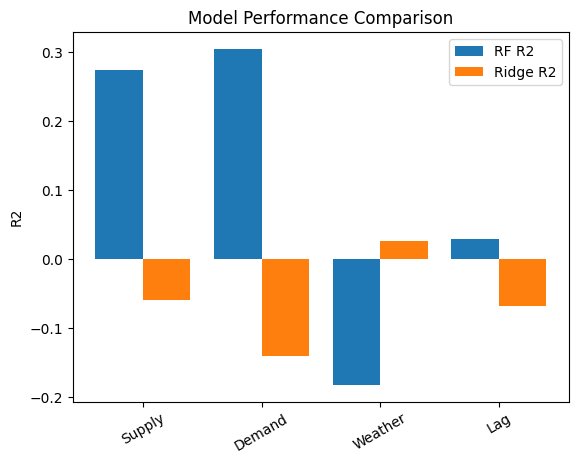

In [5]:
# --------------------------------
# Model Performance Visualization
# --------------------------------

import matplotlib.pyplot as plt

# Extract R2 scores from each feature group
model_names = list(results.keys())
rf_r2 = [results[m]["rf_r2"] for m in model_names]
ridge_r2 = [results[m]["ridge_r2"] for m in model_names]
x = range(len(model_names))

plt.figure()

# Compare Random Forest and Ridge Regression performance
plt.bar(x, rf_r2, width=0.4, label="RF R2")
plt.bar([i + 0.4 for i in x], ridge_r2, width=0.4, label="Ridge R2")

# Format chart labels and layout
plt.xticks([i + 0.2 for i in x], model_names, rotation=30)
plt.ylabel("R2")
plt.title("Model Performance Comparison")
plt.legend()
plt.show()

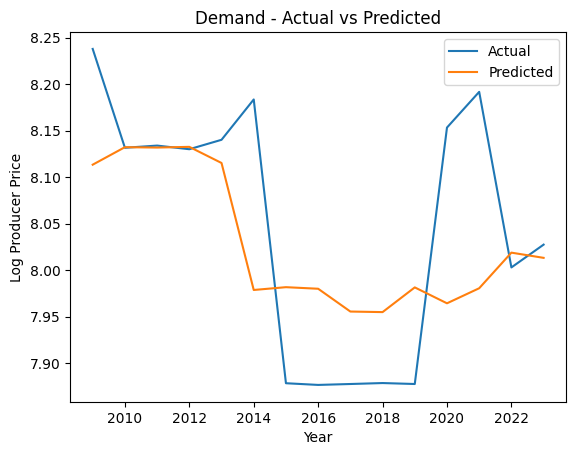

In [7]:
# ----------------------------------------
# Actual vs Predicted Price Visualization
# ----------------------------------------

# Select the Random Forest model with the highest R2 score
best_model = max(results, key=lambda x: results[x]["rf_r2"])

# Extract actual and predicted log producer prices
y_actual = master_model[TARGET].values
y_pred = results[best_model]["rf_preds"]

# Match prediction years with actual observations
years = master_model.index[-len(y_pred):]
y_actual = y_actual[-len(y_pred):]

plt.figure()

# Compare actual values with model predictions over time
plt.plot(years, y_actual, label="Actual")
plt.plot(years, y_pred, label="Predicted")

# Format plot labels and title
plt.title(f"{best_model} - Actual vs Predicted")
plt.xlabel("Year")
plt.ylabel("Log Producer Price")

plt.legend()
plt.show()

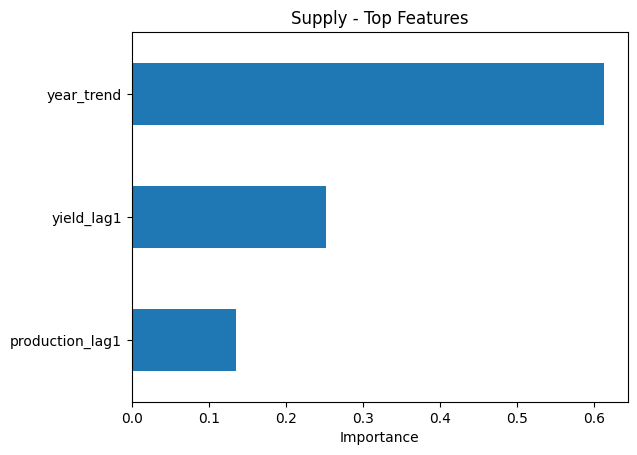

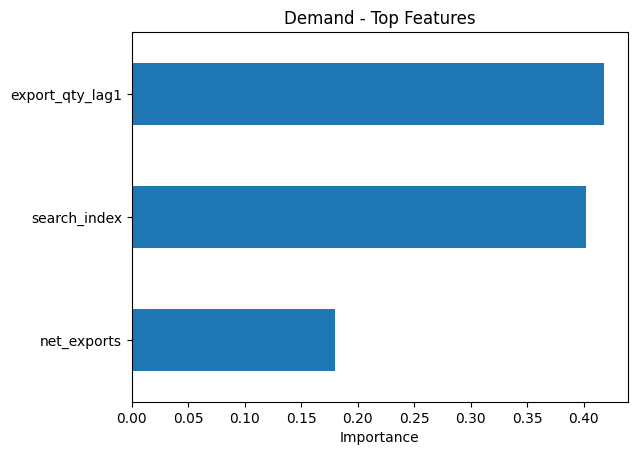

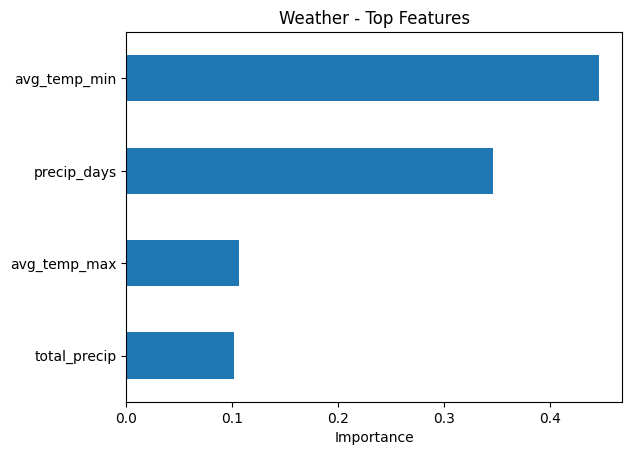

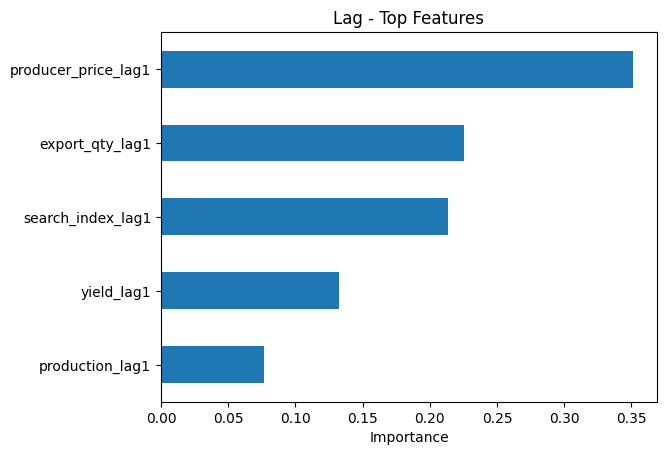

In [8]:

# Visualize Random Forest feature importance for each model group
for model_name, res in results.items():

# Sort and plot feature importance values
    res["rf_importance"].sort_values().plot(kind="barh")

  # Format plot labels and title
    plt.title(f"{model_name} - Top Features")
    plt.xlabel("Importance")
    plt.ylabel("")
    plt.show()